## Fully Connected Neuronal Net (FCNN) am Beispiel des MNIST - Datensatzes

Als Beispiel für ein Fully Connected Neuronal Net (FCNN) wird der MNIST - Datensatz verwendet. Dieser Datensatz besteht aus handgeschriebenen Ziffern (0-9) und ist ein Standard-Datensatz für die Evaluierung von Bildklassifikationsalgorithmen.

In [270]:
#load modules


import numpy as np
import os

import datetime
import matplotlib.pyplot as plt
#--------------------------------------------------
# TensorFlow import
#-------------------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
import tensorflow.python.util.deprecation as deprecation
deprecation._PRINT_DEPRECATION_WARNINGS = False

##### Laden des MNIST - Datensatzes

Der Datsatz kann direkt über die Bibliothek `tensorflow` geladen werden. Dabei werden die Bilder in Trainings- und Testdaten aufgeteilt. Jedes Bild hat eine Größe von 28x28 Pixeln und ist in Graustufen.

In [271]:
#--------------------------------------------------
# Load MNIST-Datensatzes Dataset using Keras
#--------------------------------------------------
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

In [272]:
# Analyze and investigate data Structure
print(f"Trainingsdaten: {X_train.shape}, Labels: {y_train.shape}")



Trainingsdaten: (60000, 28, 28), Labels: (60000,)


##### Anzeige der Daten

Jede Ziffer wird einmal angezeigt

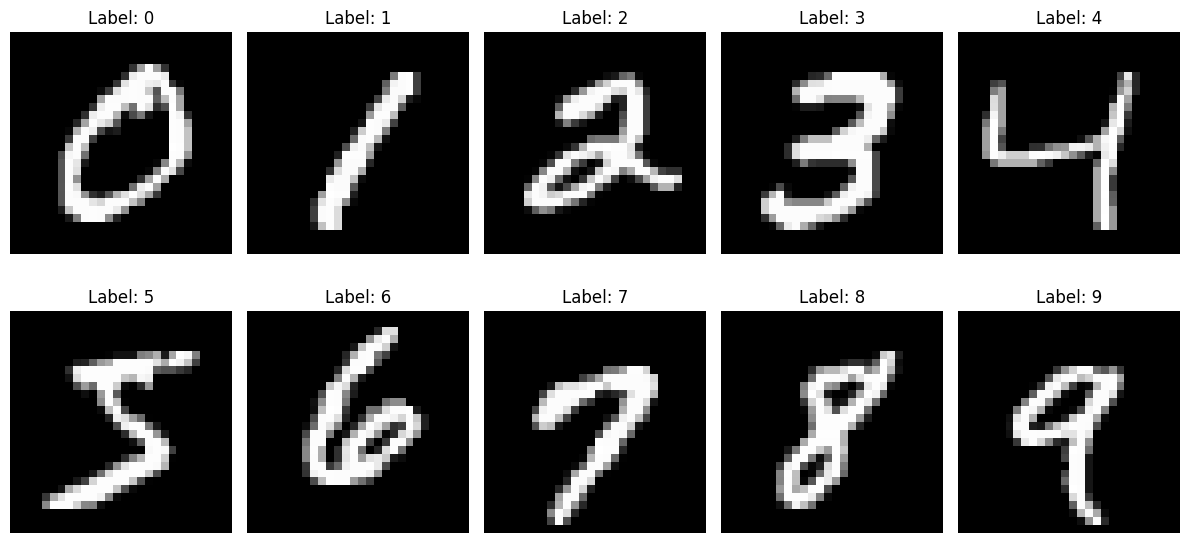

In [273]:
# Create a figure to display the images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel() # Flatten the 2x5 grid into a 1D array

# Loop through each digit from 0 to 9
for i in range(10):
    # Find the first index of the current digit in the training labels
    idx = np.where(y_train == i)[0][0]
    
    # Get the corresponding image from the training data
    image = X_train[idx]
    
    # Display the image on the appropriate subplot
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"Label: {i}")
    axes[i].axis('off') # Hide the axes

plt.tight_layout()
plt.show()

##### Vorbereitung der Daten 

Die Daten müssen für die Eingabe in das FCNN vorbereitet werden. Dazu werden die 28x28 Pixel großen Bilder in Vektoren der Länge 784 (28*28) umgewandelt. Außerdem werden die Pixelwerte normalisiert, indem sie durch 255 geteilt werden, um Werte zwischen 0 und 1 zu erhalten.

Die Labels werden in eine One-Hot_Kodieriung umgewandelt. D.h. die Labels (Ziffern 0-9) werden in einen binären Vektor der Länge 10 umgewandelt, wobei die Position der Ziffer auf 1 gesetzt wird und alle anderen Positionen auf 0. Zum Beispiel wird die Ziffer '3' als [0, 0, 0, 1, 0, 0, 0, 0, 0, 0] kodiert.

In [274]:
#--------------------------------------------------
# Flatten
#--------------------------------------------------
X_train = X_train.reshape(-1, 28 * 28)
X_test  = X_test.reshape(-1, 28 * 28)

#--------------------------------------------------
# Normieren
#--------------------------------------------------
X_train   = X_train / 255
X_test  = X_test  / 255

#--------------------------------------------------
# One-Hot-Kodierung
#--------------------------------------------------
y_train_oneHot = tf.keras.utils.to_categorical(y_train, 10)
y_test_oneHot = tf.keras.utils.to_categorical(y_test, 10)

##### Anzeigen der abgewandelten Datenstruktur

In [275]:
print(f"Trainingsdaten: {X_train.shape}, Labels: {y_train_oneHot.shape}")

print(f"One-Hot-Encoding: \n {y_train_oneHot[0:10,:]}")

print(f"Beispiel-Bild (Ausschnitt): \n {X_train[55][200:250]}")

Trainingsdaten: (60000, 784), Labels: (60000, 10)
One-Hot-Encoding: 
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]]
Beispiel-Bild (Ausschnitt): 
 [0.         0.         0.         0.         0.         0.
 0.         0.03137255 0.37254902 0.85098039 0.99215686 0.99215686
 0.99215686 0.99215686 0.99215686 0.99215686 0.99215686 0.99215686
 0.99215686 0.97254902 0.04313725 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.10588235 0.83529412
 0.99215686 0.99215686 0.94117647 0.56078431 0.43529412 0.59607843
 0.99215686 0.99215686 0.99215686 0.99215686 0.76078431 0.24313725
 0.         0.        ]


In [276]:
#--------------------------------------------------# Define and KERAS / TensorFlow Sequential Model)
#--------------------------------------------------# define initila values initializers
init_kernel = tf.keras.initializers.RandomNormal(mean=0., stddev=1.)
init_bias   = tf.keras.initializers.RandomNormal(mean=0., stddev=1.)

model_fcn = Sequential()
model_fcn.add(tf.keras.Input(shape=(28*28,)))
model_fcn.add(tf.keras.layers.Dense(64, activation="sigmoid", kernel_initializer = init_kernel, bias_initializer = init_bias))
model_fcn.add(tf.keras.layers.Dense(32, activation="sigmoid",kernel_initializer = init_kernel, bias_initializer = init_bias))
model_fcn.add(tf.keras.layers.Dense(10, activation="sigmoid",kernel_initializer = init_kernel, bias_initializer = init_bias))

model_fcn.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_58 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

In [277]:
#--------------------------------------------------
# define custom MSE loss function  
#--------------------------------------------------
def my_mse(y_true,y_pred):
    L = tf.reduce_mean(tf.square(tf.subtract(y_true,y_pred)))
    return L

In [278]:
#--------------------------------------------------
# Modell kompilieren
#------------------------------------------------

model_fcn.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.7), loss="MeanSquaredError", metrics=['accuracy'])

#--------------------------------------------------
# Modell trainieren
#--------------------------------------------------
history_fcn = model_fcn.fit(X_train, y_train_oneHot, batch_size=35, epochs=150, verbose=1)

Epoch 1/150
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 2s 802us/step - accuracy: 0.1022 - loss: 0.2214
Epoch 2/150
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 1s 796us/step - accuracy: 0.1045 - loss: 0.1525
Epoch 3/150
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 1s 801us/step - accuracy: 0.1046 - loss: 0.1407
Epoch 4/150
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - accuracy: 0.1046 - loss: 0.1332
Epoch 5/150
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 2s 875us/step - accuracy: 0.1062 - loss: 0.1270
Epoch 6/150
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 2s 869us/step - accuracy: 0.6568 - loss: 0.0511
Epoch 7/150
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 1s 809us/step - accuracy: 0.7832 - loss: 0.0353
Epoch 8/150
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 1s 806us/step - accuracy: 0.8098 - loss: 0.0313
Epoch 9/150
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 1s 826us/step - accuracy: 0.8246 - loss: 0.0287
Epoch 10/150
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step - accuracy: 0.8355 - loss: 0.0268
Epoch 11/150
1715/1715 ━━━━━━━━━━━━━━━━━━━━ 1s 811us/step - accuracy: 0.8445 - loss: 0.02

------------------------------------------
Klassifikationsgenauigkeit (Trainingsende)
------------------------------------------
96.18833065032959  Prozent


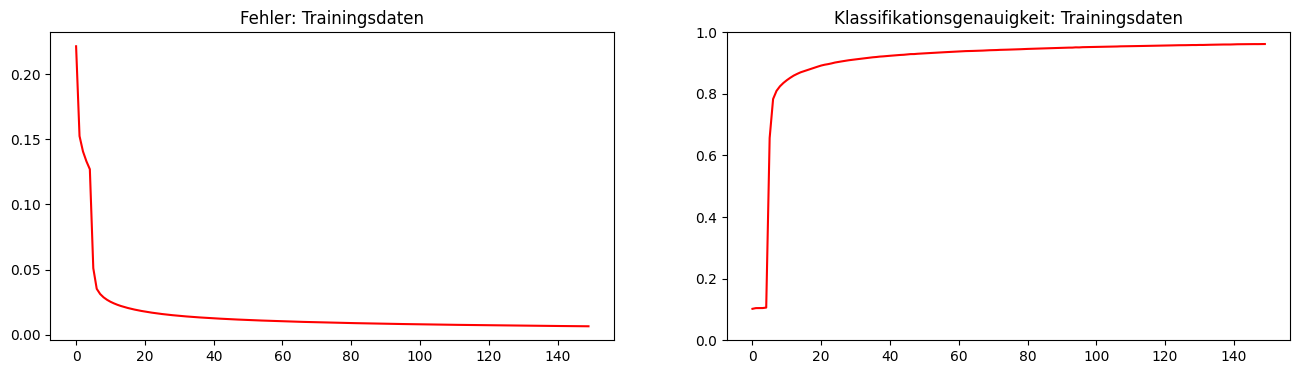

In [279]:
fig, ax = plt.subplots(1,2, squeeze=False,figsize=(16, 4))

ax[0,0].plot(history_fcn.history['loss'],"r")
ax[0,1].plot(history_fcn.history['accuracy'],"r")
ax[0,1].set_ylim([0,1])


ax[0,0].set_title("Fehler: Trainingsdaten")
t=ax[0,1].set_title("Klassifikationsgenauigkeit: Trainingsdaten")

print("------------------------------------------")
print("Klassifikationsgenauigkeit (Trainingsende)")
print("------------------------------------------")
print(np.max(history_fcn.history['accuracy'])*100 , " Prozent")

In [280]:
# klassifikation auf Testdaten durchführen
test_loss, test_accuracy = model_fcn.evaluate(X_test, y_test_oneHot, verbose=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 754us/step - accuracy: 0.9430 - loss: 0.0090


In [281]:
print("------------------------------------------")
print("Klassifikationsgenauigkeit Testdate )")
print("------------------------------------------")
print(test_accuracy*100 , " Prozent")


------------------------------------------
Klassifikationsgenauigkeit Testdate )
------------------------------------------
94.30000185966492  Prozent


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


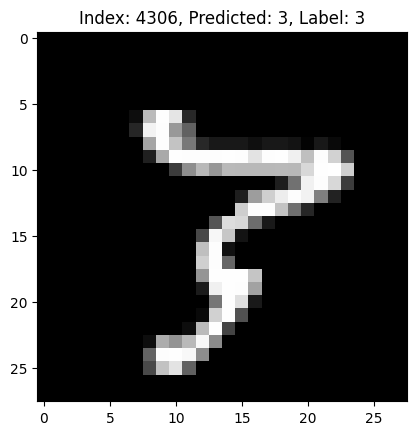

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


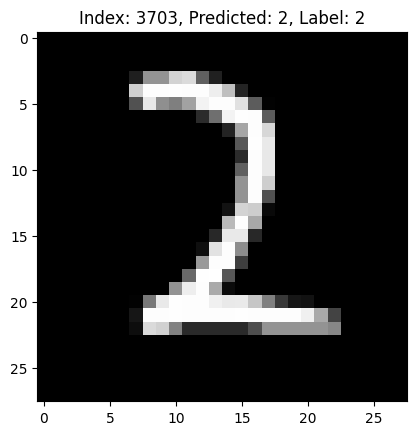

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


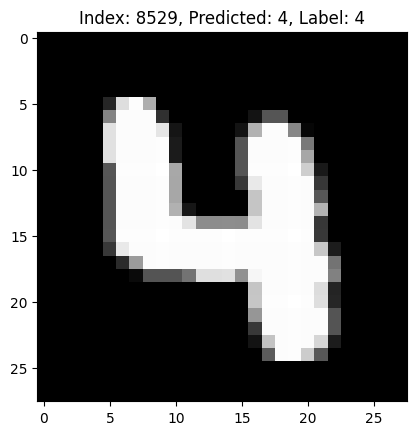

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


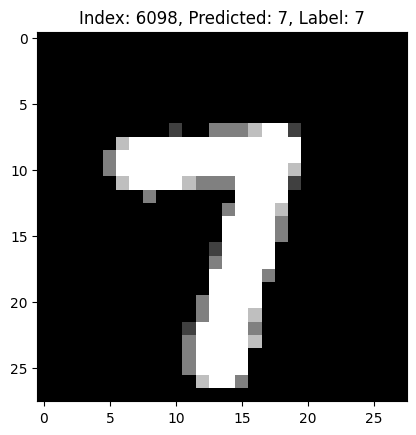

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


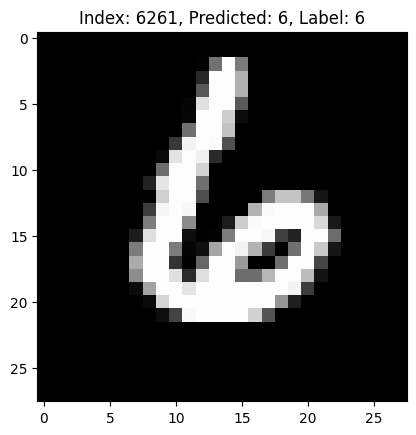

In [282]:
# 10 random numbers from test set
random_indices = np.random.randint(0, X_test.shape[0], size=5)

for index in random_indices:
    example_image = X_test[index,:].reshape(1,28*28)
    example_label = y_test[index]
    example_prediction = model_fcn.predict(example_image)
    predicted_label = np.argmax(example_prediction)

    #print(f'index {index}')
    #print(f'predicted {predicted_label}')
    #print(f'actual {example_label}')

    plt.figure()
    plt.imshow(example_image.reshape(28,28), cmap='gray')
    plt.title(f'Index: {index}, Predicted: {predicted_label}, Label: {example_label}')
    plt.show()


In [283]:
# identify and print misclassified examples
predictions = model_fcn.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)
misclassified_indices = np.where(predicted_labels != y_test)[0]
print(f'Anzahl falsch klassifizierter Objekte: {misclassified_indices.shape}')
print(predictions.shape)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step
Anzahl falsch klassifizierter Objekte: (570,)
(10000, 10)


Falsche Klassifizierungen: 570


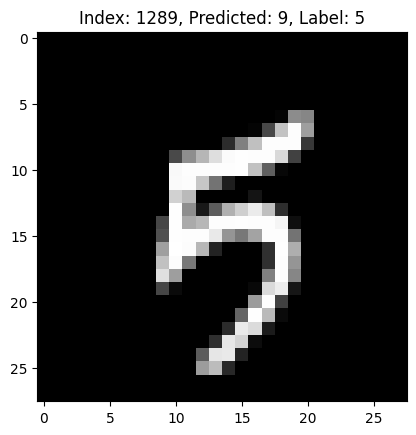

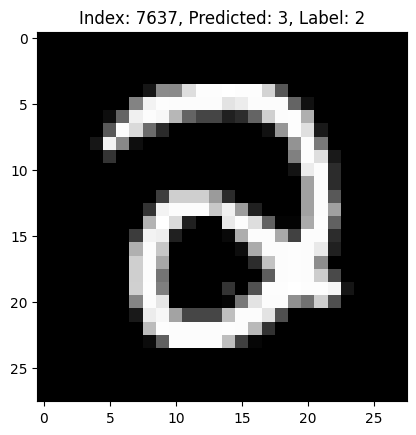

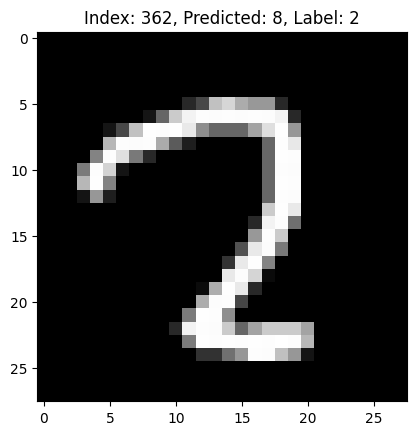

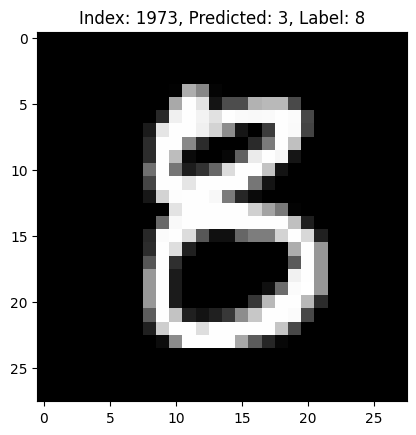

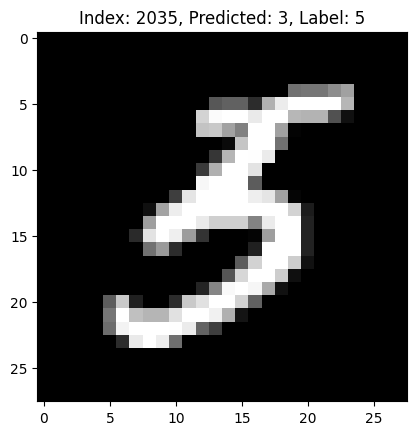

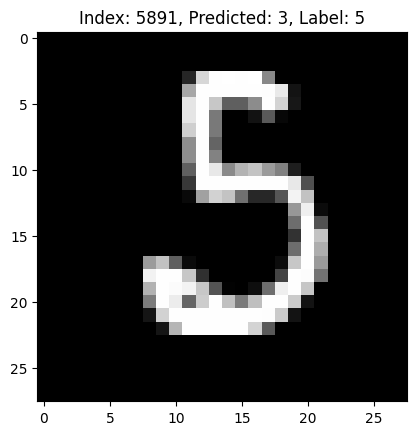

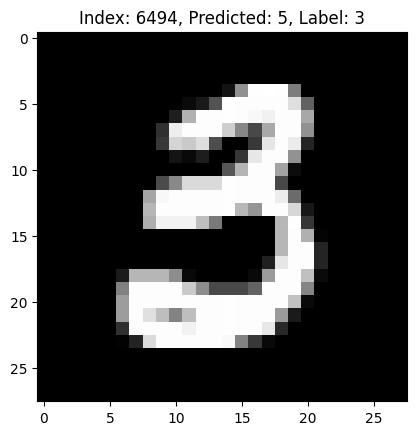

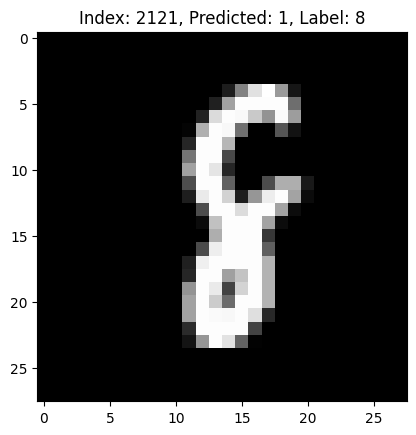

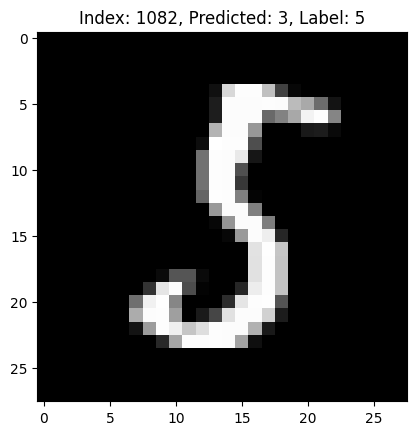

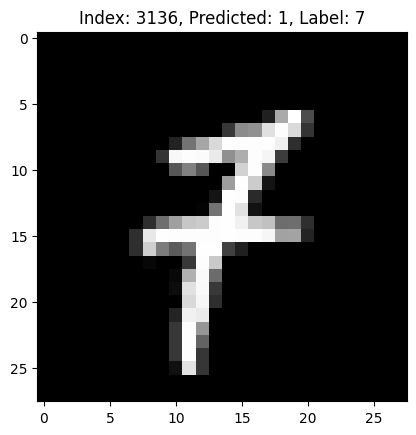

In [285]:
print(f'Falsche Klassifizierungen: {misclassified_indices.shape[0]}')


# print number of misclassified examples
indices = np.random.randint(0, misclassified_indices.shape[0], size=10)

for id in indices:
    index = misclassified_indices[id]
    example_image = X_test[index,:].reshape(28,28)
    predicted_label = predicted_labels[index]
    actual_label = y_test[index]

    plt.figure()
    plt.imshow(example_image, cmap='gray')
    plt.title(f'Index: {index}, Predicted: {predicted_label}, Label: {actual_label}')
    plt.show()